## Problem Statement

### Predict whether an employee is likely to leave the company based on employee information.

In [166]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.compose import ColumnTransformer, make_column_transformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler,OneHotEncoder, LabelEncoder
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, recall_score, precision_score, confusion_matrix, classification_report, f1_score, roc_auc_score, roc_curve, precision_recall_curve

In [2]:
df = pd.read_csv('Employee Attrition.csv')
df.head()

,Age,Attrition,BusinessTravel,DailyRate,Department,DistanceFromHome,Education,EducationField,EmployeeCount,EmployeeNumber,...,RelationshipSatisfaction,StandardHours,StockOptionLevel,TotalWorkingYears,TrainingTimesLastYear,WorkLifeBalance,YearsAtCompany,YearsInCurrentRole,YearsSinceLastPromotion,YearsWithCurrManager
0,41,Yes,Travel_Rarely,1102,Sales,1,2,Life Sciences,1,1,...,1,80,0,8,0,1,6,4,0,5
1,49,No,Travel_Frequently,279,Research & Development,8,1,Life Sciences,1,2,...,4,80,1,10,3,3,10,7,1,7
2,37,Yes,Travel_Rarely,1373,Research & Development,2,2,Other,1,4,...,2,80,0,7,3,3,0,0,0,0
3,33,No,Travel_Frequently,1392,Research & Development,3,4,Life Sciences,1,5,...,3,80,0,8,3,3,8,7,3,0
4,27,No,Travel_Rarely,591,Research & Development,2,1,Medical,1,7,...,4,80,1,6,3,3,2,2,2,2


# EDA

In [3]:
df.shape

(1470, 35)

In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1470 entries, 0 to 1469
Data columns (total 35 columns):
 #   Column                    Non-Null Count  Dtype 
---  ------                    --------------  ----- 
 0   Age                       1470 non-null   int64 
 1   Attrition                 1470 non-null   object
 2   BusinessTravel            1470 non-null   object
 3   DailyRate                 1470 non-null   int64 
 4   Department                1470 non-null   object
 5   DistanceFromHome          1470 non-null   int64 
 6   Education                 1470 non-null   int64 
 7   EducationField            1470 non-null   object
 8   EmployeeCount             1470 non-null   int64 
 9   EmployeeNumber            1470 non-null   int64 
 10  EnvironmentSatisfaction   1470 non-null   int64 
 11  Gender                    1470 non-null   object
 12  HourlyRate                1470 non-null   int64 
 13  JobInvolvement            1470 non-null   int64 
 14  JobLevel                

In [5]:
df.describe()

,Age,DailyRate,DistanceFromHome,Education,EmployeeCount,EmployeeNumber,EnvironmentSatisfaction,HourlyRate,JobInvolvement,JobLevel,...,RelationshipSatisfaction,StandardHours,StockOptionLevel,TotalWorkingYears,TrainingTimesLastYear,WorkLifeBalance,YearsAtCompany,YearsInCurrentRole,YearsSinceLastPromotion,YearsWithCurrManager
count,1470.000000,1470.000000,1470.000000,1470.000000,1470.0,1470.000000,1470.000000,1470.000000,1470.000000,1470.000000,...,1470.000000,1470.0,1470.000000,1470.000000,1470.000000,1470.000000,1470.000000,1470.000000,1470.000000,1470.000000
mean,36.923810,802.485714,9.192517,2.912925,1.0,1024.865306,2.721769,65.891156,2.729932,2.063946,...,2.712245,80.0,0.793878,11.279592,2.799320,2.761224,7.008163,4.229252,2.187755,4.123129
std,9.135373,403.509100,8.106864,1.024165,0.0,602.024335,1.093082,20.329428,0.711561,1.106940,...,1.081209,0.0,0.852077,7.780782,1.289271,0.706476,6.126525,3.623137,3.222430,3.568136
min,18.000000,102.000000,1.000000,1.000000,1.0,1.000000,1.000000,30.000000,1.000000,1.000000,...,1.000000,80.0,0.000000,0.000000,0.000000,1.000000,0.000000,0.000000,0.000000,0.000000
25%,30.000000,465.000000,2.000000,2.000000,1.0,491.250000,2.000000,48.000000,2.000000,1.000000,...,2.000000,80.0,0.000000,6.000000,2.000000,2.000000,3.000000,2.000000,0.000000,2.000000
50%,36.000000,802.000000,7.000000,3.000000,1.0,1020.500000,3.000000,66.000000,3.000000,2.000000,...,3.000000,80.0,1.000000,10.000000,3.000000,3.000000,5.000000,3.000000,1.000000,3.000000
75%,43.000000,1157.000000,14.000000,4.000000,1.0,1555.750000,4.000000,83.750000,3.000000,3.000000,...,4.000000,80.0,1.000000,15.000000,3.000000,3.000000,9.000000,7.000000,3.000000,7.000000
max,60.000000,1499.000000,29.000000,5.000000,1.0,2068.000000,4.000000,100.000000,4.000000,5.000000,...,4.000000,80.0,3.000000,40.000000,6.000000,4.000000,40.000000,18.000000,15.000000,17.000000


In [6]:
df.isnull().sum()

Age                         0
Attrition                   0
BusinessTravel              0
DailyRate                   0
Department                  0
DistanceFromHome            0
Education                   0
EducationField              0
EmployeeCount               0
EmployeeNumber              0
EnvironmentSatisfaction     0
Gender                      0
HourlyRate                  0
JobInvolvement              0
JobLevel                    0
JobRole                     0
JobSatisfaction             0
MaritalStatus               0
MonthlyIncome               0
MonthlyRate                 0
NumCompaniesWorked          0
Over18                      0
OverTime                    0
PercentSalaryHike           0
PerformanceRating           0
RelationshipSatisfaction    0
StandardHours               0
StockOptionLevel            0
TotalWorkingYears           0
TrainingTimesLastYear       0
WorkLifeBalance             0
YearsAtCompany              0
YearsInCurrentRole          0
YearsSince

In [7]:
df.nunique()

Age                           43
Attrition                      2
BusinessTravel                 3
DailyRate                    886
Department                     3
DistanceFromHome              29
Education                      5
EducationField                 6
EmployeeCount                  1
EmployeeNumber              1470
EnvironmentSatisfaction        4
Gender                         2
HourlyRate                    71
JobInvolvement                 4
JobLevel                       5
JobRole                        9
JobSatisfaction                4
MaritalStatus                  3
MonthlyIncome               1349
MonthlyRate                 1427
NumCompaniesWorked            10
Over18                         1
OverTime                       2
PercentSalaryHike             15
PerformanceRating              2
RelationshipSatisfaction       4
StandardHours                  1
StockOptionLevel               4
TotalWorkingYears             40
TrainingTimesLastYear          7
WorkLifeBa

In [8]:
df['Attrition'].value_counts()

Attrition
No     1233
Yes     237
Name: count, dtype: int64

In [9]:
df.duplicated().sum()

np.int64(0)

In [10]:
df.drop_duplicates(inplace = True)

In [11]:
df.shape

(1470, 35)

In [26]:
number_columns = df.select_dtypes(include = ['int64']).columns

In [27]:
category_columns = df.select_dtypes(include = ['object']).columns

<Axes: xlabel='Attrition', ylabel='count'>

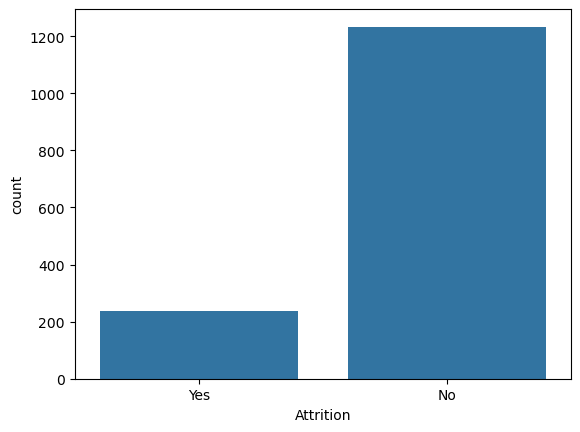

In [14]:
sns.countplot(df, x = 'Attrition')

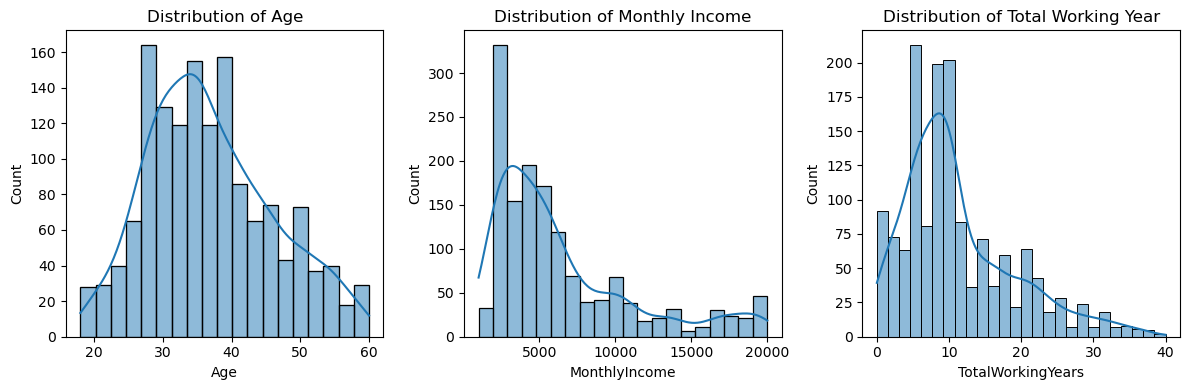

In [15]:
plt.figure(figsize=(12,4))
plt.subplot(131)
sns.histplot(df['Age'], kde = True)
plt.title('Distribution of Age')

plt.subplot(132)
sns.histplot(df['MonthlyIncome'], kde = True)
plt.title('Distribution of Monthly Income')

plt.subplot(133)
sns.histplot(df['TotalWorkingYears'], kde = True)
plt.title('Distribution of Total Working Year')

plt.tight_layout()

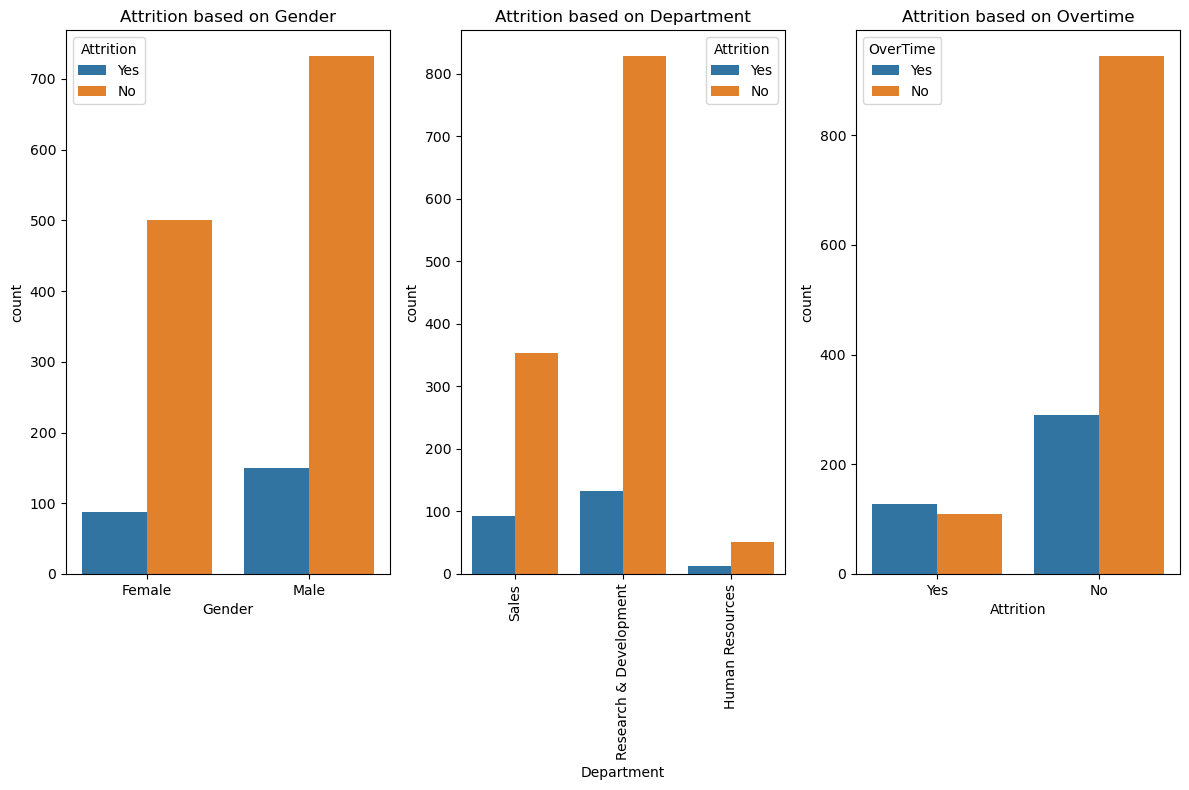

In [16]:
plt.figure(figsize=(12,8))
plt.subplot(131)
sns.countplot(df, x = 'Gender', hue = 'Attrition')
plt.title('Attrition based on Gender')

plt.subplot(132)
sns.countplot(df, x = 'Department', hue = 'Attrition')
plt.title('Attrition based on Department')
plt.xticks(rotation = 90)

plt.subplot(133)
sns.countplot(df, x = 'Attrition', hue = 'OverTime')
plt.title('Attrition based on Overtime')

plt.tight_layout()

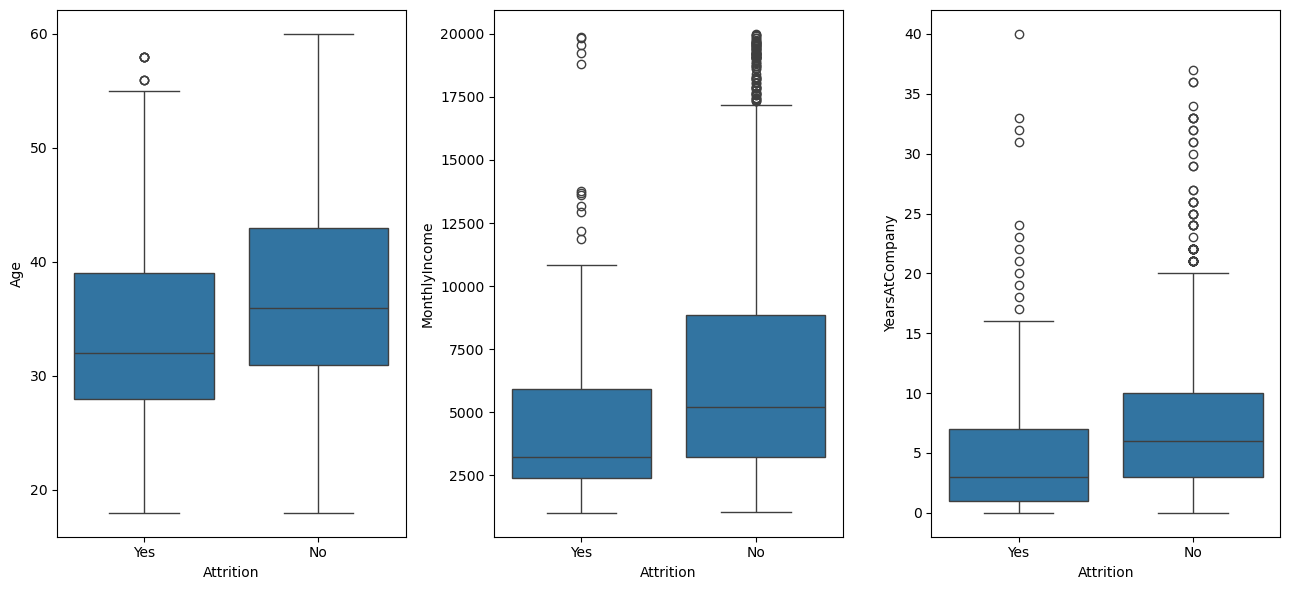

In [188]:
plt.figure(figsize=(13,6))
plt.subplot(131)
sns.boxplot(x = df['Attrition'], y = df['Age'])

plt.subplot(132)
sns.boxplot(x = df['Attrition'],y = df['MonthlyIncome'])

plt.subplot(133)
sns.boxplot(x = df['Attrition'], y = df['YearsAtCompany'])

plt.tight_layout()

In [19]:
df = df.drop(columns = ['EmployeeCount', 'EmployeeNumber','StandardHours'], axis = 1)

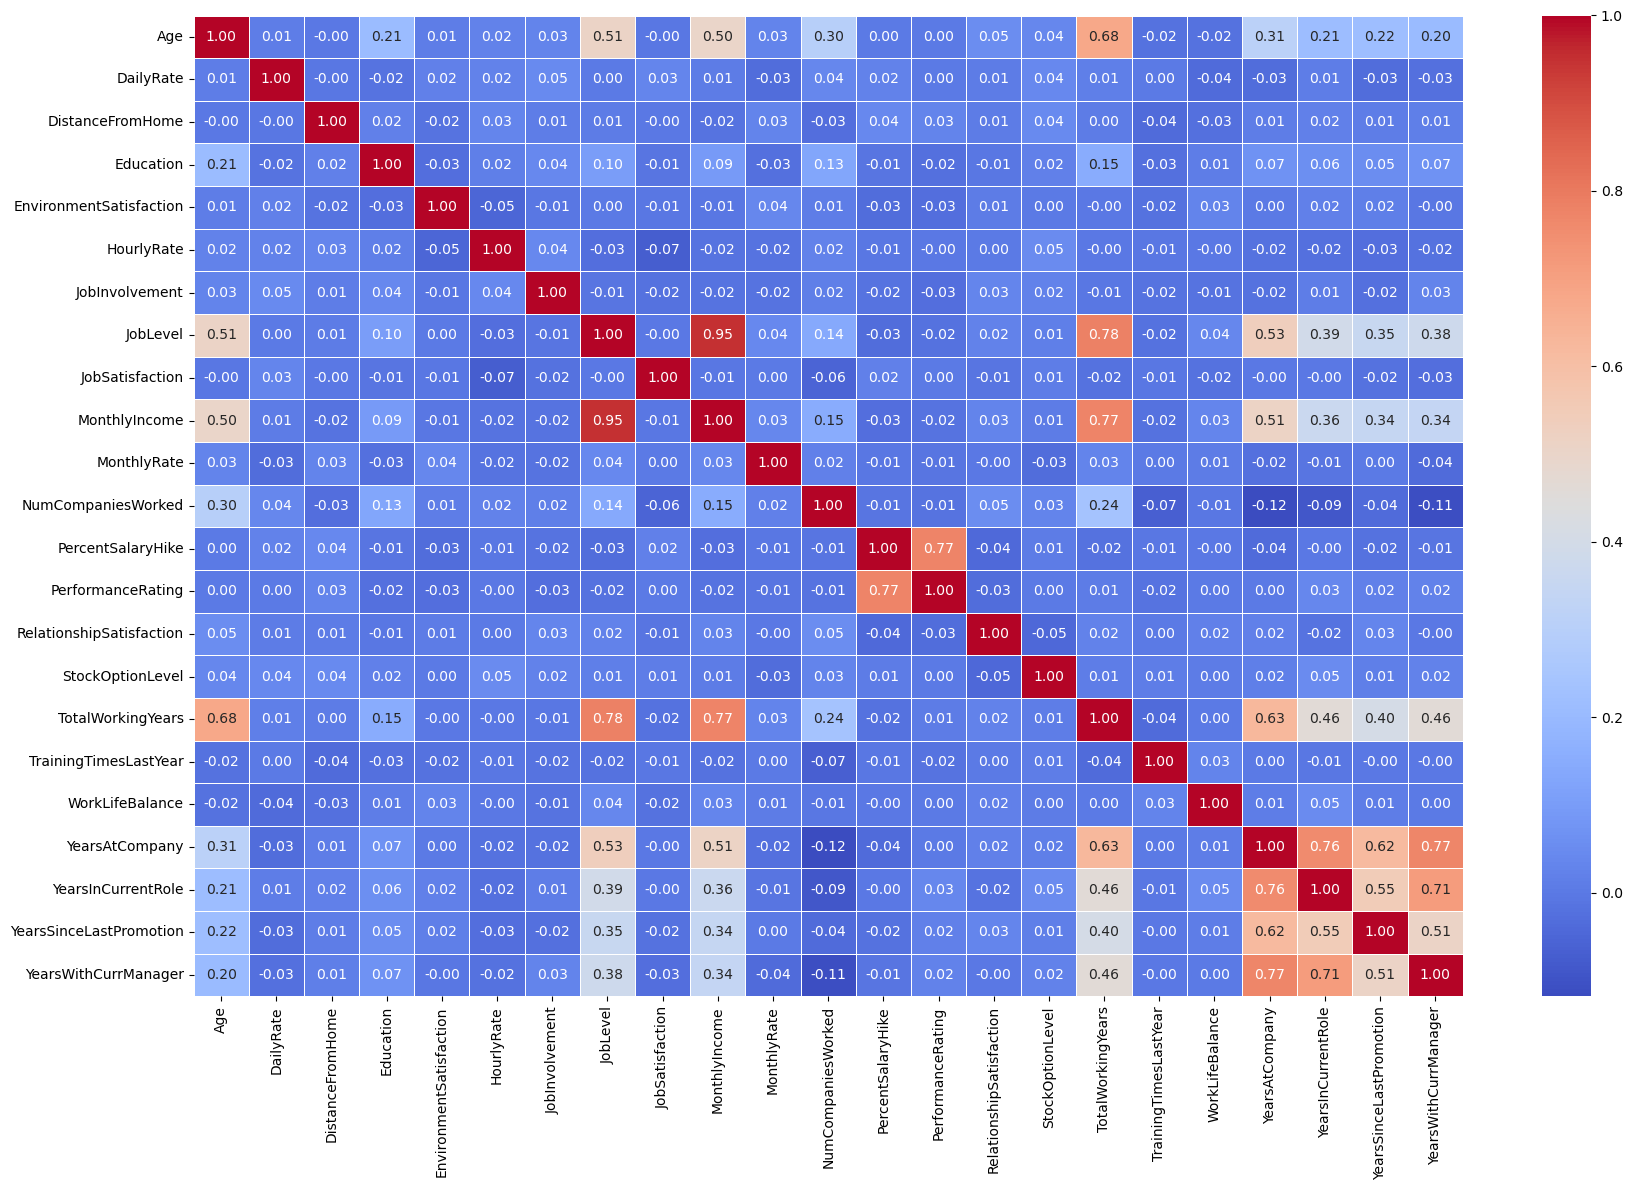

In [20]:
plt.figure(figsize = (18,12))

sns.heatmap(df.select_dtypes(include = ['int64']).corr(), annot = True, fmt = '.2f',cmap = 'coolwarm', linewidths = 0.5)

plt.tight_layout()

Text(0.5, 1.0, 'OverTime vs Attrition')

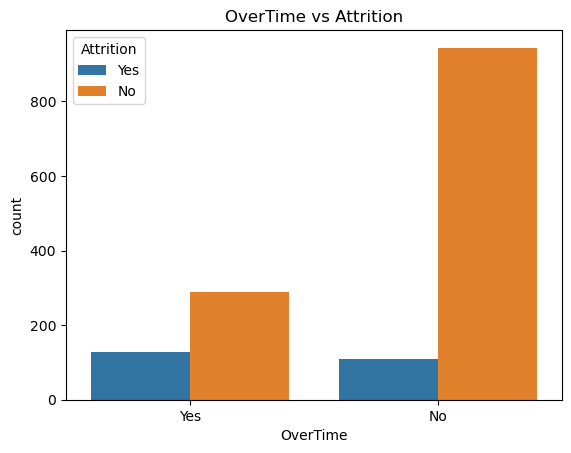

In [21]:
sns.countplot(x='OverTime', hue='Attrition', data=df)
plt.title("OverTime vs Attrition")

## Handling Outliers

X.mean + 3*X.std

In [22]:
upper_limit = df['MonthlyIncome'].mean() + 3 * df['MonthlyIncome'].std()
lower_limit = df['MonthlyIncome'].mean() - 3 * df['MonthlyIncome'].std()

In [23]:
print("Upper Limit :->",upper_limit)
print("Lower Limit :->",lower_limit)

Upper Limit :-> 20626.80164181099
Lower Limit :-> -7620.939056776979


In [24]:
df['MonthlyIncome'] = np.where(df['MonthlyIncome']> upper_limit, upper_limit, 
                               np.where(df['MonthlyIncome'] < lower_limit, lower_limit, df['MonthlyIncome']))

<Axes: ylabel='MonthlyIncome'>

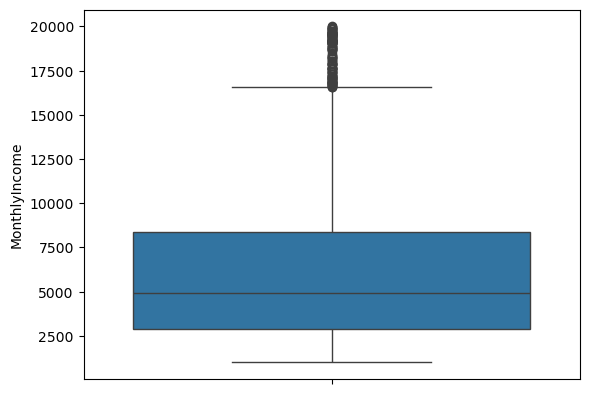

In [25]:
sns.boxplot(df['MonthlyIncome'])

In [28]:
print(number_columns)
print()
print(category_columns)

Index(['Age', 'DailyRate', 'DistanceFromHome', 'Education',
       'EnvironmentSatisfaction', 'HourlyRate', 'JobInvolvement', 'JobLevel',
       'JobSatisfaction', 'MonthlyRate', 'NumCompaniesWorked',
       'PercentSalaryHike', 'PerformanceRating', 'RelationshipSatisfaction',
       'StockOptionLevel', 'TotalWorkingYears', 'TrainingTimesLastYear',
       'WorkLifeBalance', 'YearsAtCompany', 'YearsInCurrentRole',
       'YearsSinceLastPromotion', 'YearsWithCurrManager'],
      dtype='object')

Index(['Attrition', 'BusinessTravel', 'Department', 'EducationField', 'Gender',
       'JobRole', 'MaritalStatus', 'Over18', 'OverTime'],
      dtype='object')


In [51]:
df[['Age', 'DailyRate', 'DistanceFromHome', 'Education',
       'EnvironmentSatisfaction', 'HourlyRate', 'JobInvolvement', 'JobLevel',
       'JobSatisfaction', 'MonthlyRate', 'NumCompaniesWorked',
       'PercentSalaryHike', 'PerformanceRating', 'RelationshipSatisfaction',
       'StockOptionLevel', 'TotalWorkingYears', 'TrainingTimesLastYear',
       'WorkLifeBalance', 'YearsAtCompany', 'YearsInCurrentRole',
       'YearsSinceLastPromotion', 'YearsWithCurrManager']].sample(5)

,Age,DailyRate,DistanceFromHome,Education,EnvironmentSatisfaction,HourlyRate,JobInvolvement,JobLevel,JobSatisfaction,MonthlyRate,...,PerformanceRating,RelationshipSatisfaction,StockOptionLevel,TotalWorkingYears,TrainingTimesLastYear,WorkLifeBalance,YearsAtCompany,YearsInCurrentRole,YearsSinceLastPromotion,YearsWithCurrManager
1378,42,419,12,4,2,77,3,2,4,2900,...,3,3,2,14,4,3,0,0,0,0
623,30,1012,5,4,2,75,2,1,4,2373,...,3,2,1,10,3,2,5,4,0,3
150,40,1395,26,3,2,54,3,2,2,8504,...,3,1,1,20,2,3,20,7,2,13
178,46,526,1,2,2,92,3,3,1,2137,...,4,3,3,24,2,3,24,13,15,7
665,47,1454,2,4,4,65,2,1,4,13137,...,3,1,0,3,3,2,3,2,1,2


In [52]:
df[['NumCompaniesWorked', 'PercentSalaryHike']]

,NumCompaniesWorked,PercentSalaryHike
0,8,11
1,1,23
2,6,15
3,1,11
4,9,12
...,...,...
1465,4,17
1466,4,15
1467,1,20
1468,2,14


In [103]:
df[['BusinessTravel', 'Department', 'EducationField', 'Gender',
       'JobRole', 'MaritalStatus','Over18','OverTime']].sample(5)

,BusinessTravel,Department,EducationField,Gender,JobRole,MaritalStatus,Over18,OverTime
1137,Non-Travel,Research & Development,Other,Female,Research Scientist,Married,Y,Yes
325,Travel_Frequently,Research & Development,Life Sciences,Female,Manufacturing Director,Married,Y,No
883,Travel_Rarely,Research & Development,Medical,Male,Research Scientist,Married,Y,No
35,Travel_Rarely,Research & Development,Medical,Female,Research Scientist,Divorced,Y,No
369,Travel_Rarely,Research & Development,Life Sciences,Male,Research Scientist,Single,Y,Yes


In [104]:
df['Over18'].value_counts()

Over18
Y    1470
Name: count, dtype: int64

In [106]:
df.drop('Over18', axis = 1, inplace = True)

## Encoding

In [114]:
encoding_columns = ['BusinessTravel', 'Department', 'EducationField', 'Gender', 'JobRole', 'MaritalStatus', 'OverTime']

scaling_columns = ['Age' , 'DailyRate' , 'DistanceFromHome', 'HourlyRate', 'NumCompaniesWorked', 'PercentSalaryHike', 'TotalWorkingYears', 'YearsAtCompany', 'YearsInCurrentRole', 'YearsSinceLastPromotion', 'YearsWithCurrManager']

In [115]:
processor = ColumnTransformer(transformers=[
    ('category', OneHotEncoder(drop = 'first',sparse_output = False), encoding_columns),
    ('numerical', StandardScaler(), scaling_columns)
], remainder = 'passthrough')

In [116]:
processor

ColumnTransformer(remainder='passthrough',
                  transformers=[('category',
                                 OneHotEncoder(drop='first',
                                               sparse_output=False),
                                 ['BusinessTravel', 'Department',
                                  'EducationField', 'Gender', 'JobRole',
                                  'MaritalStatus', 'OverTime']),
                                ('numerical', StandardScaler(),
                                 ['Age', 'DailyRate', 'DistanceFromHome',
                                  'HourlyRate', 'NumCompaniesWorked',
                                  'PercentSalaryHike', 'TotalWorkingYears',
                                  'YearsAtCompany', 'YearsInCurrentRole',
                                  'YearsSinceLastPromotion',
                                  'YearsWithCurrManager'])])

In [117]:
df['Attrition'].value_counts()

Attrition
No     1233
Yes     237
Name: count, dtype: int64

In [118]:
X = df.drop('Attrition', axis = 1)
y = df['Attrition'].map({'Yes' : 1, 'No' : 0})

#### Here we add stratify because attrition data is imbalance we check the shape of it and we gor No = 1233 and Yes = 237

In [119]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size = 0.2, stratify = y,random_state = 42)

## Transforming Data

In [120]:
X_train_scaled = processor.fit_transform(X_train)
X_test_scaled = processor.transform(X_test)

## Model

In [155]:
lr = LogisticRegression(class_weight = 'balanced', max_iter = 1000)
lr.fit(X_train_scaled, y_train)

C:\Users\Om\anaconda3\Lib\site-packages\sklearn\linear_model\_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


LogisticRegression(class_weight='balanced', max_iter=1000)

In [197]:
y_pred = lr.predict(X_test_scaled)

## Metrics

In [157]:
print(accuracy_score(y_test, y_pred))

0.7585034013605442


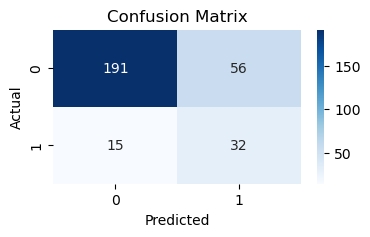

In [158]:
cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(4,2))
sns.heatmap(cm, annot = True, fmt = 'd',cmap = 'Blues')
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")
plt.show()

In [159]:
print(precision_score(y_test, y_pred))

0.36363636363636365


In [160]:
print(recall_score(y_test, y_pred))

0.6808510638297872


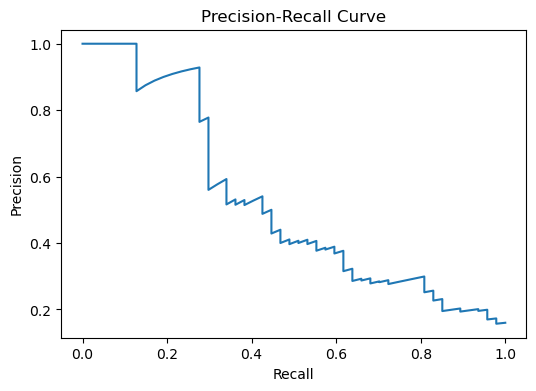

In [161]:
precision, recall, thresholds = precision_recall_curve(y_test, y_prob)

plt.figure(figsize=(6,4))
plt.plot(recall, precision)

plt.xlabel("Recall")
plt.ylabel("Precision")
plt.title("Precision-Recall Curve")
plt.show()

In [162]:
print(f1_score(y_test, y_pred))

0.4740740740740741


In [163]:
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.93      0.77      0.84       247
           1       0.36      0.68      0.47        47

    accuracy                           0.76       294
   macro avg       0.65      0.73      0.66       294
weighted avg       0.84      0.76      0.78       294



In [164]:
print(roc_auc_score(y_test, lr.predict_proba(X_test_scaled)[:, 1]))

0.8003273322422259


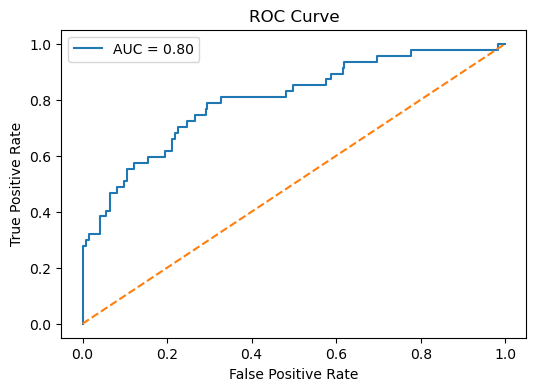

In [165]:
y_prob = lr.predict_proba(X_test_scaled)[:,1]

fpr, tpr, thresholds = roc_curve(y_test, y_prob)
auc_score = roc_auc_score(y_test, y_prob)

plt.figure(figsize=(6,4))
plt.plot(fpr, tpr, label=f"AUC = {auc_score:.2f}")
plt.plot([0,1],[0,1],'--')

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve")
plt.legend()
plt.show()

In [182]:
score = cross_val_score(lr, X_train_scaled, y_train, scoring = 'accuracy', cv = 10)

C:\Users\Om\anaconda3\Lib\site-packages\sklearn\linear_model\_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(
C:\Users\Om\anaconda3\Lib\site-packages\sklearn\linear_model\_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _c

In [183]:
print("Cross Validation Scores:", score)
print("Mean Accuracy:", np.mean(score))

Cross Validation Scores: [0.61864407 0.74576271 0.71186441 0.72033898 0.79661017 0.77966102
 0.81196581 0.77777778 0.82051282 0.81196581]
Mean Accuracy: 0.7595103578154425


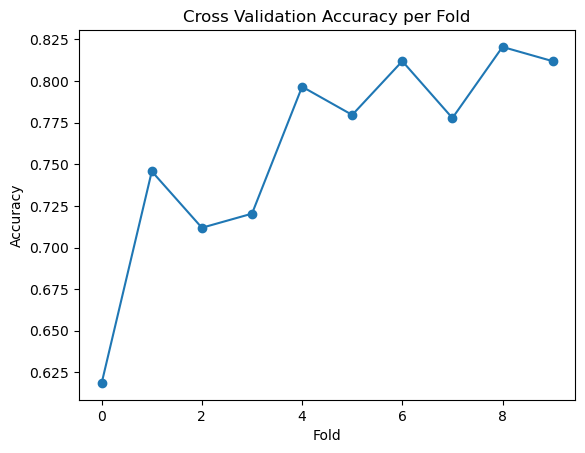

In [184]:
plt.plot(score, marker='o')
plt.title("Cross Validation Accuracy per Fold")
plt.xlabel("Fold")
plt.ylabel("Accuracy")
plt.show()

# Pickle

In [196]:
import pickle

model_data = {
    'process': processor,
    'model' : lr
}

pickle.dump(model_data, open('Employee Attrition Status.pkl', 'wb'))